# 03 — Choose Bandpass
# Giai đoạn 1 — Mục 1.2/1.3 — Chọn dải bandpass cho envelope
**Đầu ra**: `outputs/tables/bandpass_config.json`


In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import io_utils, dsp, config as cfg
from common.pipeline import pick_file
from common import order


In [3]:
OUTPUT_DIR = Path("./outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(TABLES_DIR / "manifest_clean.csv")
FS = cfg.SCOPE["sampling_rate_hz"]

# Dải cộng hưởng khai ở ĐÂY để vùng tô trên phổ FFT và giá trị chốt ghi ra
# JSON luôn là một số duy nhất (bản trước gõ tay 2300-3800 ở hai chỗ khác
# nhau, sửa một chỗ là lệch ngay).
BAND_HZ = (2300, 3800)
# 500 -> 750 Hz. Hài bậc 3 của BPFI cao nhất trong phạm vi là 486.3 Hz
# (0HP); qua lowpass Butterworth bậc 2 ở 500 Hz vạch này bị suy giảm
# -2.78 dB, tức đặc trưng envelope_BPFI_h3 bị chính bộ lọc làm méo. Ở 750 Hz
# chỉ còn -0.71 dB. Lấy từ config để nb 04/05/06 không thể lệch nhau.
LP_CUTOFF_HZ = cfg.LP_CUTOFF_HZ

## Vẽ FFT để xác định vùng cộng hưởng


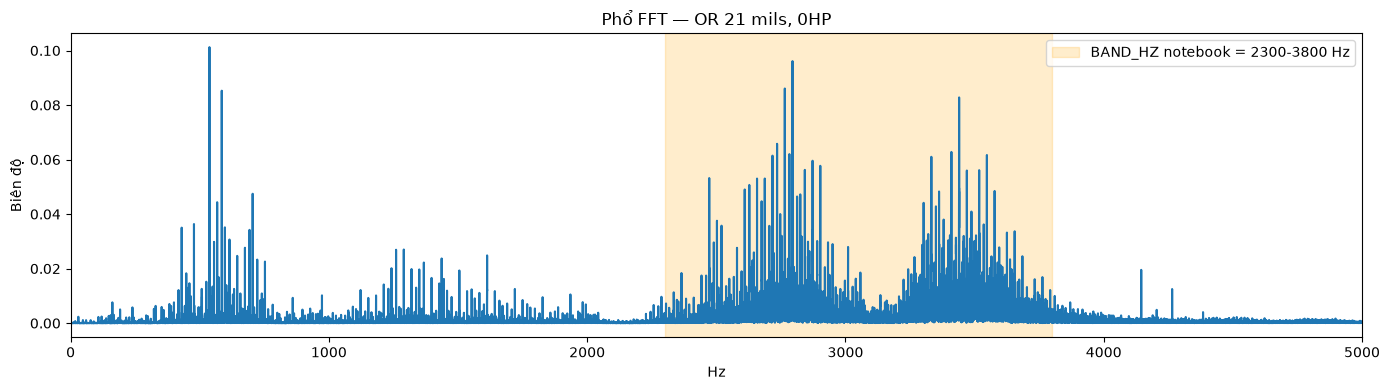

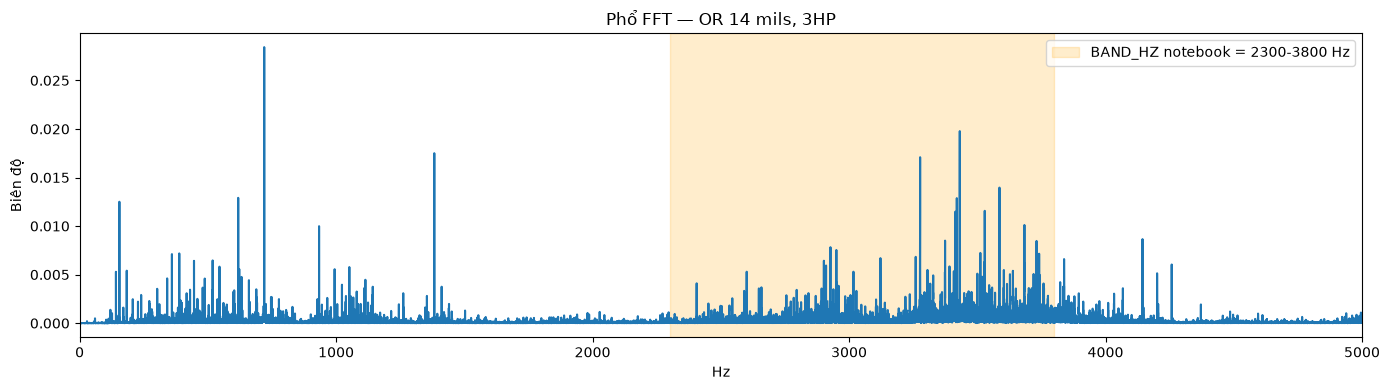

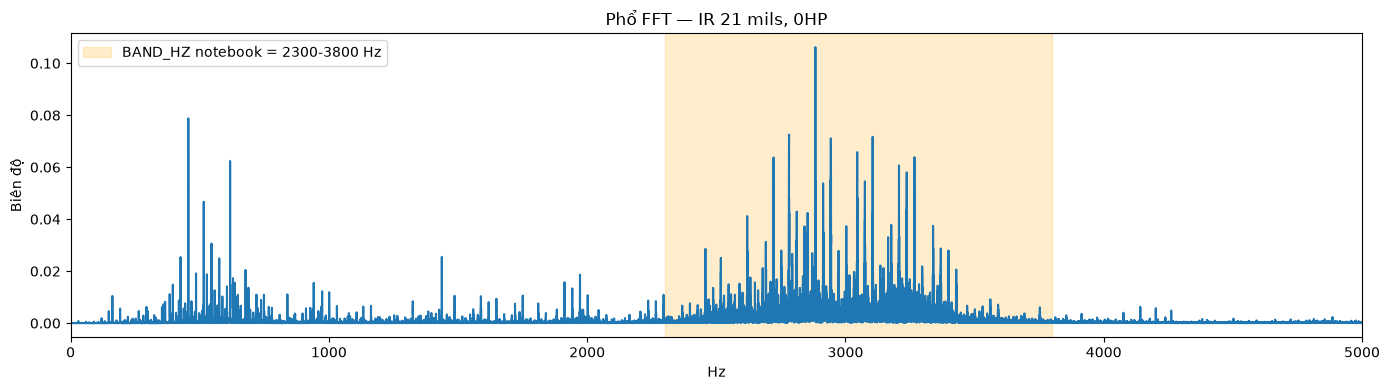

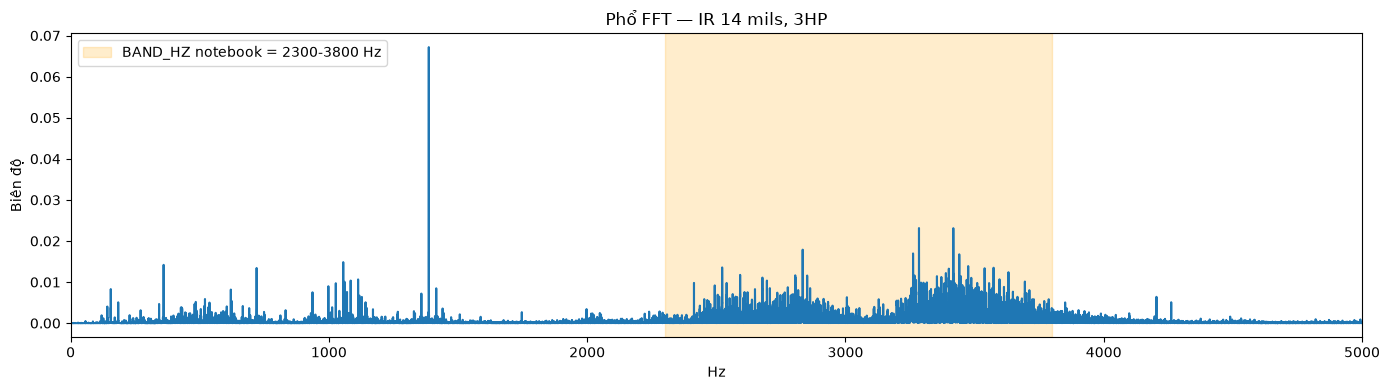

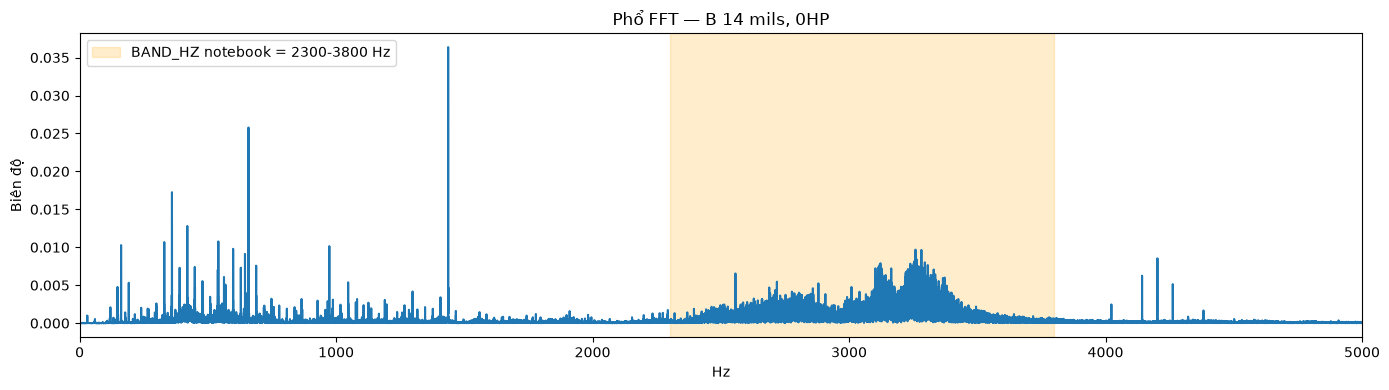

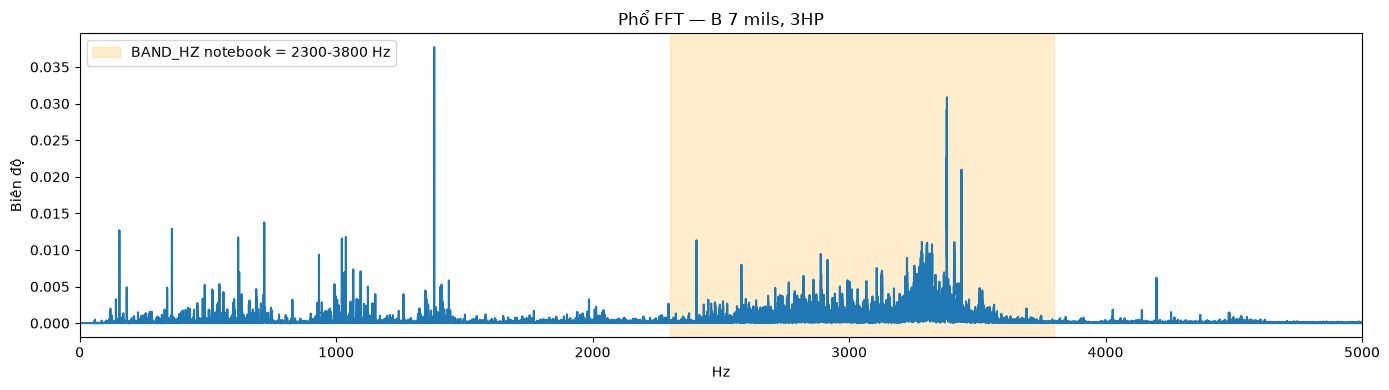

In [4]:
def plot_fft_for_band_selection(label, load_hp=0, diameter_mils=21, freq_max_hz=5000):
    if label == "Normal":
        file_path = pick_file(manifest, label=label, load_hp=load_hp)
    else:
        file_path = pick_file(manifest, label=label, load_hp=load_hp, diameter_mils=diameter_mils)

    row = manifest.loc[manifest["file_path"] == file_path].iloc[0]
    fs = int(row.get("fs", FS))
    x = io_utils.load_de_signal(Path(file_path))

    freqs, mag = dsp.compute_fft(x - np.mean(x), fs)
    plt.figure(figsize=(14, 4))
    plt.plot(freqs, mag)
    plt.xlabel("Hz")
    plt.ylabel("Biên độ")
    plt.xlim(0, freq_max_hz)
    plt.title(f"Phổ FFT — {label} {diameter_mils} mils, {load_hp}HP")

    # Tô CẢ HAI dải ứng viên để so sánh trực quan trong lúc chưa chốt xong
    # band_hz (xem thảo luận BAND_HZ vs cfg.RESONANCE_BAND_HZ ở cell cấu hình):
    #   - cam    = BAND_HZ đang khai báo trong chính notebook này
    #   - xanh   = cfg.RESONANCE_BAND_HZ (hằng số "nguồn duy nhất" ở config.py)
    # Nếu hai giá trị đã thống nhất, ô xanh sẽ trùng khít lên ô cam.
    plt.axvspan(BAND_HZ[0], BAND_HZ[1], alpha=0.2, color="orange",
                label=f"BAND_HZ notebook = {BAND_HZ[0]}-{BAND_HZ[1]} Hz")
    if tuple(cfg.RESONANCE_BAND_HZ) != tuple(BAND_HZ):
        plt.axvspan(cfg.RESONANCE_BAND_HZ[0], cfg.RESONANCE_BAND_HZ[1], alpha=0.15,
                    color="steelblue",
                    label=f"cfg.RESONANCE_BAND_HZ = {cfg.RESONANCE_BAND_HZ[0]:.0f}-{cfg.RESONANCE_BAND_HZ[1]:.0f} Hz")
    plt.legend()
    plt.tight_layout()
    out = FIGURES_DIR / f"03_fft_band_selection_{label}_{load_hp}hp.png"
    plt.savefig(out, dpi=150)
    plt.show()
    return file_path, x, fs

or_file, x_or, fs_or = plot_fft_for_band_selection("OR", load_hp=0, diameter_mils=21)
or_file_3hp, x_or_3hp, fs_or_3hp = plot_fft_for_band_selection("OR", load_hp=3, diameter_mils=14)

ir_file, x_ir, fs_ir = plot_fft_for_band_selection("IR", load_hp=0, diameter_mils=21)
ir_file_3hp, x_ir_3hp, fs_ir_3hp = plot_fft_for_band_selection("IR", load_hp=3, diameter_mils=14)

b_file_0hp, x_b_0hp, fs_b_0hp = plot_fft_for_band_selection("B", load_hp=0, diameter_mils=14)
b_file_3hp, x_b_3hp, fs_b_3hp = plot_fft_for_band_selection("B", load_hp=3, diameter_mils=7)

## Chốt bandpass


In [5]:
# Chốt giá trị cuối cùng sau khi quan sát FFT ở trên. BAND_HZ/LP_CUTOFF_HZ đã
# khai ở cell cấu hình nên vùng tô trên phổ và giá trị ghi ra JSON không thể
# lệch nhau; ở đây chỉ in lại để có vết trong notebook.
f_c_hz = 0.5 * (BAND_HZ[0] + BAND_HZ[1])
print(f"Dải cộng hưởng đã chốt : {BAND_HZ[0]}-{BAND_HZ[1]} Hz")
print(f"Tần số trung tâm f_c   : {f_c_hz:.0f} Hz")
print(f"Lowpass envelope       : {LP_CUTOFF_HZ} Hz")

Dải cộng hưởng đã chốt : 2300-3800 Hz
Tần số trung tâm f_c   : 3050 Hz
Lowpass envelope       : 750.0 Hz


### Vì sao chốt dải 2300–3800 Hz (f_c = 3050 Hz)

Hai nhãn lỗi **không** có cùng một vùng cộng hưởng, nên f_c là một **thỏa hiệp cố ý**, không phải đỉnh cộng hưởng của riêng nhãn nào:

- **OR (0HP)**: hai cụm cộng hưởng tách rời, ~2750 Hz và ~3500 Hz, và có **hõm ngay tại 3050–3150 Hz** — đúng chỗ f_c rơi vào.
- **IR (0HP)**: một đỉnh đơn quanh ~2880 Hz.

Chọn f_c = 3050 Hz vì ba lý do, theo thứ tự ưu tiên:

1. **Bao trọn cả hai cụm của OR và đỉnh của IR** trong một dải duy nhất. Một dải chung là ràng buộc bắt buộc: MCU chỉ chạy một bộ lọc, không thể đổi dải theo nhãn — nhãn chính là thứ đang cần dự đoán.
2. **f_c = 3050 Hz ≈ fs/4 = 3000 Hz**, nơi khối trực giao sai phân trung tâm của Hybrid phẳng nhất về biên độ: |Q|/|I| = sin(ω)/sin(ω_c) → 0.934 (2300 Hz), 1.000 (3050 Hz), 0.914 (3800 Hz). Đẩy f_c ra xa fs/4 làm độ nghiêng này xấu đi nhanh.
3. Hõm phổ của OR tại f_c **không phải vấn đề**: giải điều chế đường bao chỉ cần dải chứa **năng lượng bị điều biên**, không cần trúng đỉnh cộng hưởng; hai cụm 2750 và 3500 Hz đều nằm gọn trong dải.

**Ngưỡng lowpass envelope: 750 Hz** (không phải 500 Hz). Hài bậc 3 của BPFI cao nhất trong phạm vi là 486.3 Hz (0HP); qua lowpass Butterworth bậc 2 ở 500 Hz vạch này bị suy giảm −2.78 dB, tức đặc trưng `envelope_BPFI_h3` bị chính bộ lọc làm méo trước khi mô hình kịp nhìn thấy. Ở 750 Hz suy giảm còn −0.71 dB, và vẫn thấp hơn nhiều Nyquist của envelope sau khi giảm mẫu 1/2 (3000 Hz).

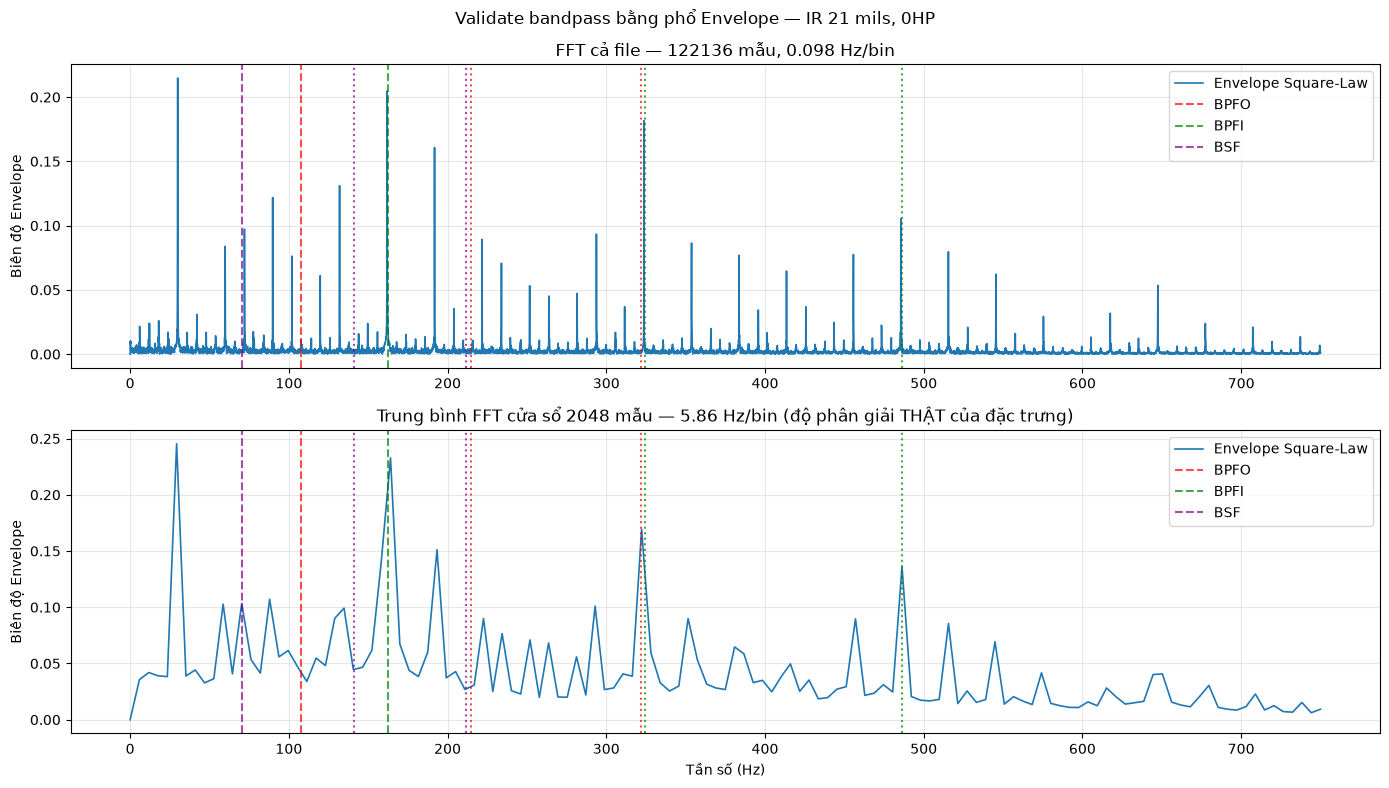

Gộp (5.86 Hz/bin không tách được): BSF_h3=211.8Hz ~ BPFO_h2=214.7Hz
Gộp (5.86 Hz/bin không tách được): BPFO_h3=322.1Hz ~ BPFI_h2=324.4Hz


In [6]:
# Validate bandpass bằng phổ envelope Square-Law trên file IR 21 mils, 0HP.
# HAI PANEL vì hai độ phân giải khác nhau, đừng đọc nhầm:
#   trên = FFT cả file (~121k mẫu -> ~0.1 Hz/bin): để NHÌN thấy vạch lỗi.
#   dưới = trung bình |FFT| trên các cửa sổ 2048 mẫu (5.86 Hz/bin): đây mới là
#          thứ MLP THẬT SỰ nhìn thấy ở notebook 04.
rpm = cfg.NOMINAL_RPM_BY_LOAD[0]
fault_freqs = cfg.bearing_fault_frequencies(rpm)
env = dsp.square_law_envelope(x_ir, fs_ir, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
env_ac = env - env.mean()
freqs_env, mag_env = dsp.compute_fft(env_ac, fs_ir)

W, S = cfg.WINDOW_SIZE_RAW, cfg.STRIDE_RAW
segs = [dsp.compute_fft(env_ac[i:i + W] - env_ac[i:i + W].mean(), fs_ir)
        for i in range(0, len(env_ac) - W + 1, S)]
freqs_w = segs[0][0]
mag_w = np.mean([m for _, m in segs], axis=0)
BIN_HZ = float(freqs_w[1] - freqs_w[0])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
panels = [(freqs_env, mag_env,
           f"FFT cả file — {len(env_ac)} mẫu, {freqs_env[1] - freqs_env[0]:.3f} Hz/bin"),
          (freqs_w, mag_w,
           f"Trung bình FFT cửa sổ {W} mẫu — {BIN_HZ:.2f} Hz/bin (độ phân giải THẬT của đặc trưng)")]
for ax, (fr, mg, ttl) in zip(axes, panels):
    mask = fr <= LP_CUTOFF_HZ
    ax.plot(fr[mask], mg[mask], label="Envelope Square-Law", linewidth=1.2)
    for name, color in {"BPFO": "red", "BPFI": "green", "BSF": "purple"}.items():
        for h in (1, 2, 3):
            f = fault_freqs[name] * h
            if f <= LP_CUTOFF_HZ:
                ax.axvline(f, color=color, linestyle="--" if h == 1 else ":",
                           alpha=0.7, label=name if h == 1 else None)
    ax.set_title(ttl)
    ax.set_ylabel("Biên độ Envelope")
    ax.grid(alpha=0.3)
    ax.legend()
axes[-1].set_xlabel("Tần số (Hz)")
fig.suptitle("Validate bandpass bằng phổ Envelope — IR 21 mils, 0HP")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_validate_bandpass_envelope.png", dpi=150)
plt.show()

# Cặp hài KHÔNG tách được ở độ phân giải thật -> order.py gộp thành 1 cột
groups, gray = order.plan_harmonic_groups(BIN_HZ)
for grp in groups:
    if len(grp) > 1:
        print(f"Gộp ({BIN_HZ:.2f} Hz/bin không tách được): "
              + " ~ ".join(f"{n}_h{h}={fault_freqs[n] * h:.1f}Hz" for n, h, _ in grp))
if gray:
    print("Sát ngưỡng, cần theo dõi:", gray)


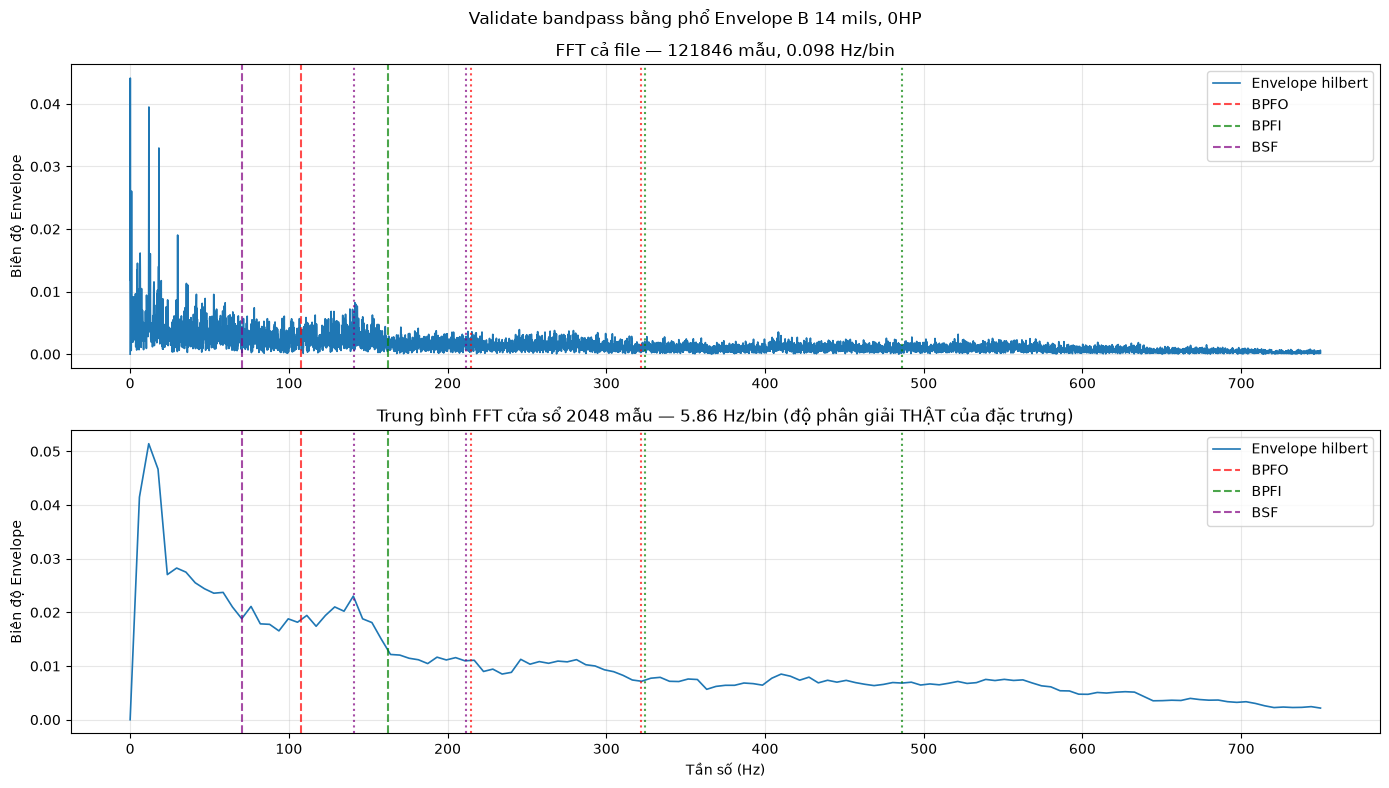

Gộp (5.86 Hz/bin không tách được): BSF_h3=211.8Hz ~ BPFO_h2=214.7Hz
Gộp (5.86 Hz/bin không tách được): BPFO_h3=322.1Hz ~ BPFI_h2=324.4Hz


In [7]:
# Validate bandpass bằng phổ envelope Square-Law trên file IR 21 mils, 0HP.
# HAI PANEL vì hai độ phân giải khác nhau, đừng đọc nhầm:
#   trên = FFT cả file (~121k mẫu -> ~0.1 Hz/bin): để NHÌN thấy vạch lỗi.
#   dưới = trung bình |FFT| trên các cửa sổ 2048 mẫu (5.86 Hz/bin): đây mới là
#          thứ MLP THẬT SỰ nhìn thấy ở notebook 04.
rpm = cfg.NOMINAL_RPM_BY_LOAD[0]
fault_freqs = cfg.bearing_fault_frequencies(rpm)
env = dsp.hilbert_envelope(x_b_0hp, fs_b_0hp, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
env_ac = env - env.mean()
freqs_env, mag_env = dsp.compute_fft(env_ac, fs_b_0hp)

W, S = cfg.WINDOW_SIZE_RAW, cfg.STRIDE_RAW
segs = [dsp.compute_fft(env_ac[i:i + W] - env_ac[i:i + W].mean(), fs_b_0hp)
        for i in range(0, len(env_ac) - W + 1, S)]
freqs_w = segs[0][0]
mag_w = np.mean([m for _, m in segs], axis=0)
BIN_HZ = float(freqs_w[1] - freqs_w[0])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
panels = [(freqs_env, mag_env,
           f"FFT cả file — {len(env_ac)} mẫu, {freqs_env[1] - freqs_env[0]:.3f} Hz/bin"),
          (freqs_w, mag_w,
           f"Trung bình FFT cửa sổ {W} mẫu — {BIN_HZ:.2f} Hz/bin (độ phân giải THẬT của đặc trưng)")]
for ax, (fr, mg, ttl) in zip(axes, panels):
    mask = fr <= LP_CUTOFF_HZ
    ax.plot(fr[mask], mg[mask], label="Envelope hilbert", linewidth=1.2)
    for name, color in {"BPFO": "red", "BPFI": "green", "BSF": "purple"}.items():
        for h in (1, 2, 3):
            f = fault_freqs[name] * h
            if f <= LP_CUTOFF_HZ:
                ax.axvline(f, color=color, linestyle="--" if h == 1 else ":",
                           alpha=0.7, label=name if h == 1 else None)
    ax.set_title(ttl)
    ax.set_ylabel("Biên độ Envelope")
    ax.grid(alpha=0.3)
    ax.legend()
axes[-1].set_xlabel("Tần số (Hz)")
fig.suptitle("Validate bandpass bằng phổ Envelope B 14 mils, 0HP")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_validate_bandpass_envelope_hilbert.png", dpi=150)
plt.show()

# Cặp hài KHÔNG tách được ở độ phân giải thật -> order.py gộp thành 1 cột
groups, gray = order.plan_harmonic_groups(BIN_HZ)
for grp in groups:
    if len(grp) > 1:
        print(f"Gộp ({BIN_HZ:.2f} Hz/bin không tách được): "
              + " ~ ".join(f"{n}_h{h}={fault_freqs[n] * h:.1f}Hz" for n, h, _ in grp))
if gray:
    print("Sát ngưỡng, cần theo dõi:", gray)


## Lưu cấu hình


In [8]:
# Ghi kèm fs và bậc lọc để hạ nguồn (notebook 04/05/06 và giai đoạn 2) không
# phải đoán lại, kèm độ nghiêng biên độ |Q|/|I| = sin(w)/sin(w_c) của khối
# trực giao sai phân trung tâm trên chính dải đã chốt. Ba con số này phải
# khớp đề cương: 1.000 tại f_c, 0.934 mép dưới, 0.914 mép trên.
f_c_hz = 0.5 * (BAND_HZ[0] + BAND_HZ[1])
w_c = 2 * np.pi * f_c_hz / FS
tilt = {str(int(f)): round(float(abs(np.sin(2 * np.pi * f / FS) / np.sin(w_c))), 4)
        for f in (BAND_HZ[0], f_c_hz, BAND_HZ[1])}

# Suy giảm của lowpass envelope tại vạch đặc trưng cao nhất (BPFI h3, tải 0HP)
f_bpfi_h3 = 3 * cfg.bearing_fault_frequencies(max(cfg.NOMINAL_RPM_BY_LOAD.values()))["BPFI"]
lp_gain = 1 / np.sqrt(1 + (f_bpfi_h3 / LP_CUTOFF_HZ) ** (2 * dsp.BENCHMARK_LOWPASS_ORDER))
print(f"BPFI h3 = {f_bpfi_h3:.1f} Hz -> lowpass giữ {20 * np.log10(lp_gain):.2f} dB")

config = {
    "band_hz": list(BAND_HZ),
    "lp_cutoff_hz": LP_CUTOFF_HZ,
    "fs_hz": int(FS),
    "f_c_hz": float(f_c_hz),
    "bandpass_order": dsp.BENCHMARK_BANDPASS_ORDER,
    "lowpass_order": dsp.BENCHMARK_LOWPASS_ORDER,
    "hybrid_amplitude_tilt": tilt,
    # Cấu hình cửa sổ: ghi ra đây để notebook 04/05/06 và giai đoạn 2
    # đọc từ MỘT nguồn, không gõ lại.
    "window_size_raw": cfg.WINDOW_SIZE_RAW,
    "stride_raw": cfg.STRIDE_RAW,
    "env_decim": cfg.ENV_DECIM,
    "window_size_env": cfg.WINDOW_SIZE_ENV,
    "stride_env": cfg.STRIDE_ENV,
    "fs_env_hz": FS / cfg.ENV_DECIM,
    "warmup_samples": cfg.WARMUP_SAMPLES,
    "freq_resolution_hz": round(FS / cfg.WINDOW_SIZE_RAW, 4),
    "lowpass_gain_at_bpfi_h3_db": round(float(20 * np.log10(lp_gain)), 2),
}
with open(TABLES_DIR / "bandpass_config.json", "w") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("Đã lưu cấu hình bandpass:")
print(json.dumps(config, indent=2, ensure_ascii=False))

BPFI h3 = 486.6 Hz -> lowpass giữ -0.71 dB
Đã lưu cấu hình bandpass:
{
  "band_hz": [
    2300,
    3800
  ],
  "lp_cutoff_hz": 750.0,
  "fs_hz": 12000,
  "f_c_hz": 3050.0,
  "bandpass_order": 4,
  "lowpass_order": 2,
  "hybrid_amplitude_tilt": {
    "2300": 0.9339,
    "3050": 1.0,
    "3800": 0.9139
  },
  "window_size_raw": 2048,
  "stride_raw": 1024,
  "env_decim": 2,
  "window_size_env": 1024,
  "stride_env": 512,
  "fs_env_hz": 6000.0,
  "warmup_samples": 2048,
  "freq_resolution_hz": 5.8594,
  "lowpass_gain_at_bpfi_h3_db": -0.71
}


In [12]:
CANDIDATE_LP_HZ = (500, 600, 700, 750, 800, 1000, 1500)  # ứng viên đã cân nhắc, để lại vết so sánh trong code
for fc in CANDIDATE_LP_HZ:
    gain = 1 / np.sqrt(1 + (f_bpfi_h3 / fc) ** (2 * dsp.BENCHMARK_LOWPASS_ORDER))
    print(f"fc={fc:>4} Hz -> BPFI_h3 ({f_bpfi_h3:.1f} Hz) suy giảm {20*np.log10(gain):.2f} dB")

fc= 500 Hz -> BPFI_h3 (486.6 Hz) suy giảm -2.78 dB
fc= 600 Hz -> BPFI_h3 (486.6 Hz) suy giảm -1.56 dB
fc= 700 Hz -> BPFI_h3 (486.6 Hz) suy giảm -0.91 dB
fc= 750 Hz -> BPFI_h3 (486.6 Hz) suy giảm -0.71 dB
fc= 800 Hz -> BPFI_h3 (486.6 Hz) suy giảm -0.56 dB
fc=1000 Hz -> BPFI_h3 (486.6 Hz) suy giảm -0.24 dB
fc=1500 Hz -> BPFI_h3 (486.6 Hz) suy giảm -0.05 dB


In [ ]:
N = 2                     # dsp.BENCHMARK_LOWPASS_ORDER
NYQ_ENV = 12000 / 2 / 2   # fs/env_decim/2 = 3000 Hz

f_bpfi_h3 = 3 * 5.4152 * (1797 / 60)   # 486.56 Hz

def atten_db(f, fc, N=N):
    return -10 * np.log10(1 + (f / fc) ** (2 * N))

def fc_for_tol(f, tol_db):
    """Dao nguoc cong thuc Butterworth: fc de dat dung tol_db tai f."""
    return f / (10 ** (tol_db / 10) - 1) ** (1 / (2 * N))

TOL_DISTORTION_DB, TOL_ALIAS_DB = 1.0, 20.0
fc_min = fc_for_tol(f_bpfi_h3, TOL_DISTORTION_DB)   # can fc >= fc_min de giu BPFI_h3
fc_max = fc_for_tol(NYQ_ENV,  TOL_ALIAS_DB)         # can fc <= fc_max de con chan alias

for fc in (500, 600, 750, 800, 1000, 1500):
    d, a = atten_db(f_bpfi_h3, fc), atten_db(NYQ_ENV, fc)
    print(f"fc={fc:>5} | meo BPFI_h3={d:6.2f} dB (đạt={abs(d)<=TOL_DISTORTION_DB!s:5}) | "
          f"chắn alias={a:6.2f} dB (đạt={abs(a)>=TOL_ALIAS_DB!s:5})")

fc=  500 | meo BPFI_h3= -2.78 dB (đạt=False) | chắn alias=-31.13 dB (đạt=True )
fc=  600 | meo BPFI_h3= -1.56 dB (đạt=False) | chắn alias=-27.97 dB (đạt=True )
fc=  700 | meo BPFI_h3= -0.91 dB (đạt=True ) | chắn alias=-25.29 dB (đạt=True )
fc=  750 | meo BPFI_h3= -0.71 dB (đạt=True ) | chắn alias=-24.10 dB (đạt=True )
fc=  800 | meo BPFI_h3= -0.56 dB (đạt=True ) | chắn alias=-22.98 dB (đạt=True )
fc= 1000 | meo BPFI_h3= -0.24 dB (đạt=True ) | chắn alias=-19.14 dB (đạt=False)
fc= 1500 | meo BPFI_h3= -0.05 dB (đạt=True ) | chắn alias=-12.30 dB (đạt=False)
